   Feature1  Feature2  Label
0  5.147623  1.350238      1
1  5.597768 -0.519110      1
2 -2.529443  7.427720      0
3  5.460525  1.669881      1
4  5.074541  5.086271      1
(300, 3)


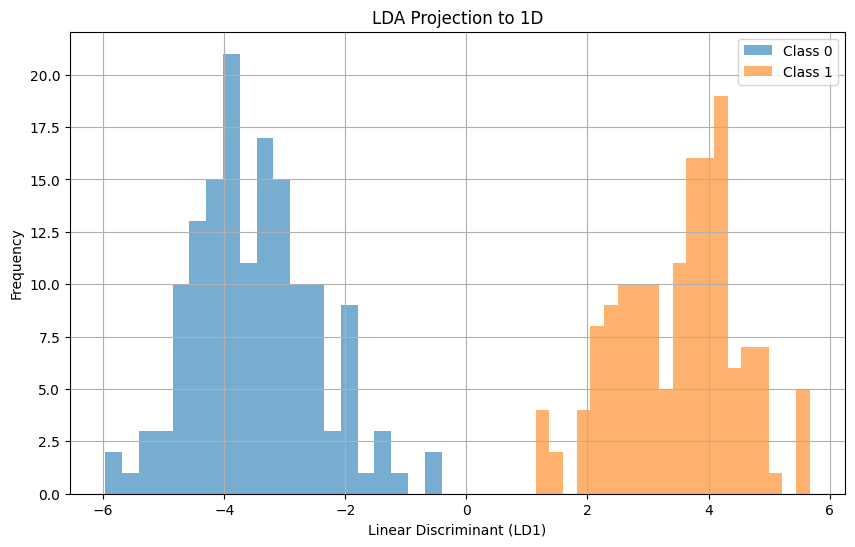


Class Means in Projected Space:
Class
0   -3.502261
1    3.502261
Name: LD1, dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load data
df = pd.read_csv("lda_gaussian.csv")

print(df.head())
print(df.shape)

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LDA
lda = LinearDiscriminantAnalysis(
    n_components=1
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

# Create dataframe
lda_df = pd.DataFrame({
    'LD1': X_lda.flatten(),
    'Class': y
})

# Histogram
plt.figure(figsize=(10,6))

for label in np.unique(y):

    subset = lda_df[
        lda_df['Class'] == label
    ]

    plt.hist(
        subset['LD1'],
        bins=20,
        alpha=0.6,
        label=f'Class {label}'
    )

plt.xlabel('Linear Discriminant (LD1)')
plt.ylabel('Frequency')
plt.title('LDA Projection to 1D')
plt.legend()
plt.grid(True)
plt.show()

# Class means
print(
    "\nClass Means in Projected Space:"
)

print(
    lda_df.groupby('Class')['LD1'].mean()
)

In [ ]:
# Do the two classes separate clearly after projection?
# Yes, the classes separate clearly.
# What property of the dataset helps LDA perform well?
# Large distance between class means
# Small variance within classes
# How are class means positioned in the projected space?
# 0   -3.502261
# 1    3.502261
# Would PCA also perform well here? Why or why not?
# PCA maximize variance and reduce feature and LDA for class seperable and reduce features so when data is known LDA is preferred

   Feature1  Feature2  Label
0  0.803926 -0.291407      1
1  2.314433 -0.122238      1
2 -0.280392  0.450938      1
3  0.789446  0.384060      0
4  1.186657 -0.511438      1
(300, 3)


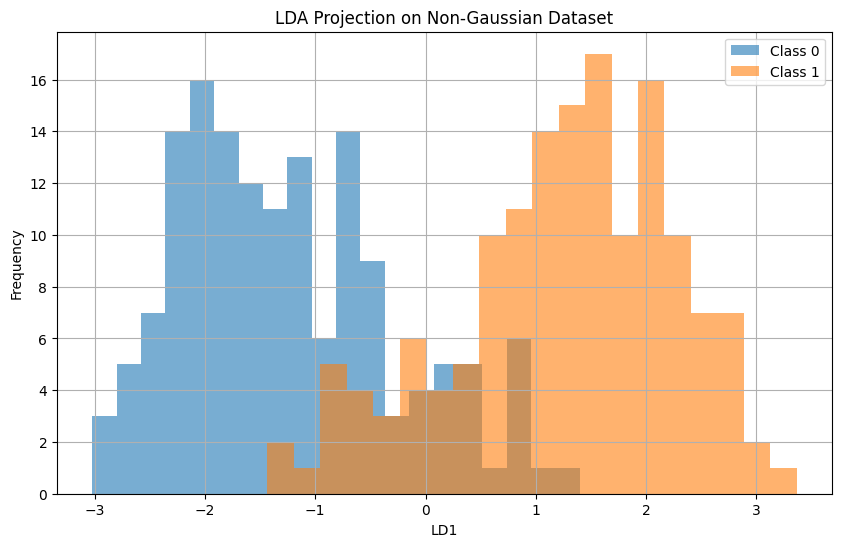

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
df = pd.read_csv("lda_nongaussian.csv")

print(df.head())
print(df.shape)

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply LDA
lda = LinearDiscriminantAnalysis(
    n_components=1
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

# Create dataframe
lda_df = pd.DataFrame({
    'LD1': X_lda.flatten(),
    'Class': y
})

# Histogram
plt.figure(figsize=(10,6))

for label in np.unique(y):

    subset = lda_df[
        lda_df['Class'] == label
    ]

    plt.hist(
        subset['LD1'],
        bins=20,
        alpha=0.6,
        label=f'Class {label}'
    )

plt.xlabel('LD1')
plt.ylabel('Frequency')
plt.title('LDA Projection on Non-Gaussian Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Is class separation as clear as in the Gaussian dataset?
# No Class separation is not as clear as in the Gaussian dataset.Separation exists, but it is imperfect.
#     This indicates that classification errors are likely in the overlapping region.

# What assumption of LDA is violated here?
# The data is not Gaussian (not normally distributed)

# How does the shape of the data affect LDA performance
# Increased overlap
# Less distinct projections
# Reduced classification accuracy

# Would PCA perform better or worse here? Explain.
# PCA would generally perform worse because it ignores class labels and only maximizes variance. Even with violated assumptions, LDA usually outperforms PCA in class separation because it explicitly uses class information.
    

   Feature1  Feature2  Label
0  0.496714 -0.138264      0
1  0.647689  1.523030      0
2 -0.234153 -0.234137      0
3  1.579213  0.767435      0
4 -0.469474  0.542560      0
(300, 3)


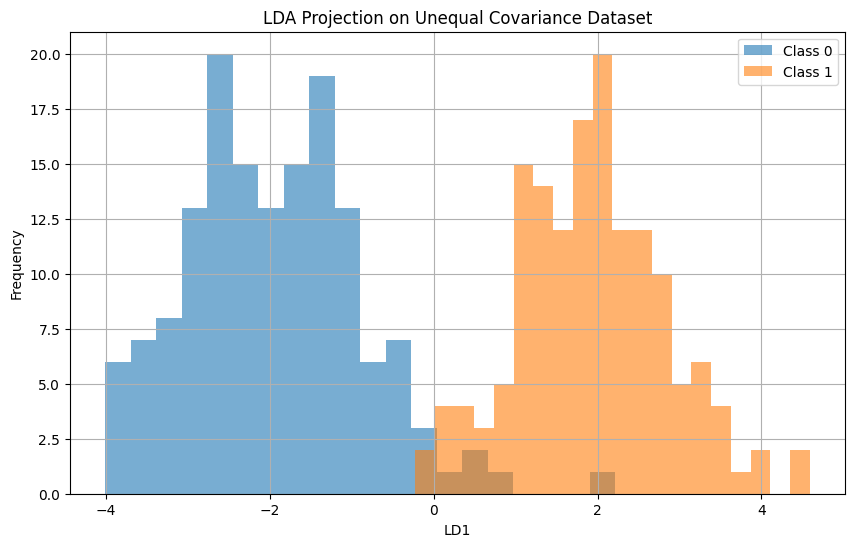


Covariance Matrix of Class 0
[[ 0.17825266 -0.00364671]
 [-0.00364671  0.34986431]]

Covariance Matrix of Class 1
[[0.93764093 0.01700916]
 [0.01700916 0.15097569]]


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
df = pd.read_csv("lda_unequal_covariance.csv")

print(df.head())
print(df.shape)

# Features and labels
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply LDA
lda = LinearDiscriminantAnalysis(
    n_components=1
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

# Create dataframe
lda_df = pd.DataFrame({
    'LD1': X_lda.flatten(),
    'Class': y
})

# Histogram
plt.figure(figsize=(10,6))

for label in np.unique(y):

    subset = lda_df[
        lda_df['Class'] == label
    ]

    plt.hist(
        subset['LD1'],
        bins=20,
        alpha=0.6,
        label=f'Class {label}'
    )

plt.xlabel('LD1')
plt.ylabel('Frequency')
plt.title(
    'LDA Projection on Unequal Covariance Dataset'
)
plt.legend()
plt.grid(True)
plt.show()

# Covariance matrices
for label in np.unique(y):

    cov = np.cov(
        X_scaled[y==label].T
    )

    print(
        f"\nCovariance Matrix of Class {label}"
    )

    print(cov)

Features: 5
Classes: 4
Maximum Components: 3
Shape after LDA:
(400, 3)


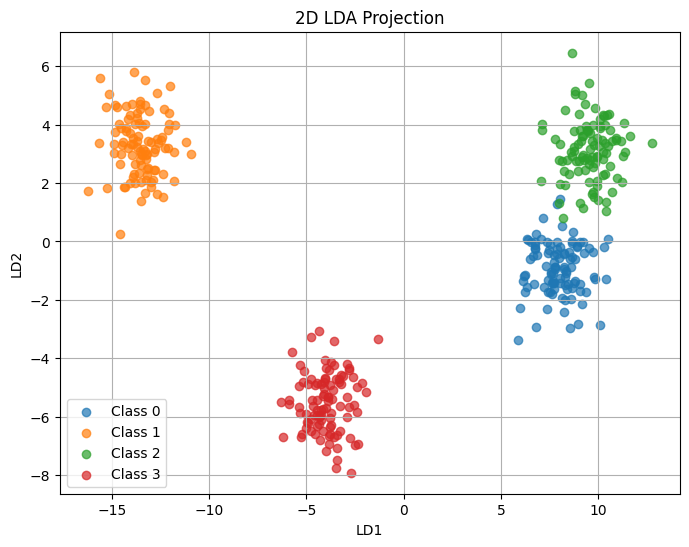

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

df = pd.read_csv("lda_multiclass.csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_classes = len(np.unique(y))
n_features = X.shape[1]

max_components = min(
    n_features,
    n_classes - 1
)

print("Features:", n_features)
print("Classes:", n_classes)
print("Maximum Components:", max_components)

lda = LinearDiscriminantAnalysis(
    n_components=max_components
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

print("Shape after LDA:")
print(X_lda.shape)

if max_components >= 2:

    plt.figure(figsize=(8,6))

    for label in np.unique(y):

        subset = X_lda[y == label]

        plt.scatter(
            subset[:,0],
            subset[:,1],
            alpha=0.7,
            label=f'Class {label}'
        )

    plt.xlabel("LD1")
    plt.ylabel("LD2")
    plt.title("2D LDA Projection")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# 1.	What is the maximum number of LDA components obtained? 
# 3 LDA components were identified in above example
# 2.	Verify the formula:
# components ≤ (number of classes − 1) 
# Yes Compnents 3 < 4-1
# 3.	Why can’t LDA produce more components? 
# LDA tries to maximize:Between-class variance & Minimize within-class variance = Rank(SB​)≤ 3 
# 4.	What happens to information beyond these components? 
# The remaining dimensions may have zero eigenvalues , contain no additional class-separation information and are redundant for discrimination.
# LDA discards them.


Clean Dataset Shape : (300, 5)
Noisy Dataset Shape : (300, 9)

Classes in Clean Dataset:
[0 1]

Classes in Noisy Dataset:
[0 1]

Maximum LDA Components : 1

Clean LDA Shape : (300, 1)
Noisy LDA Shape : (300, 1)


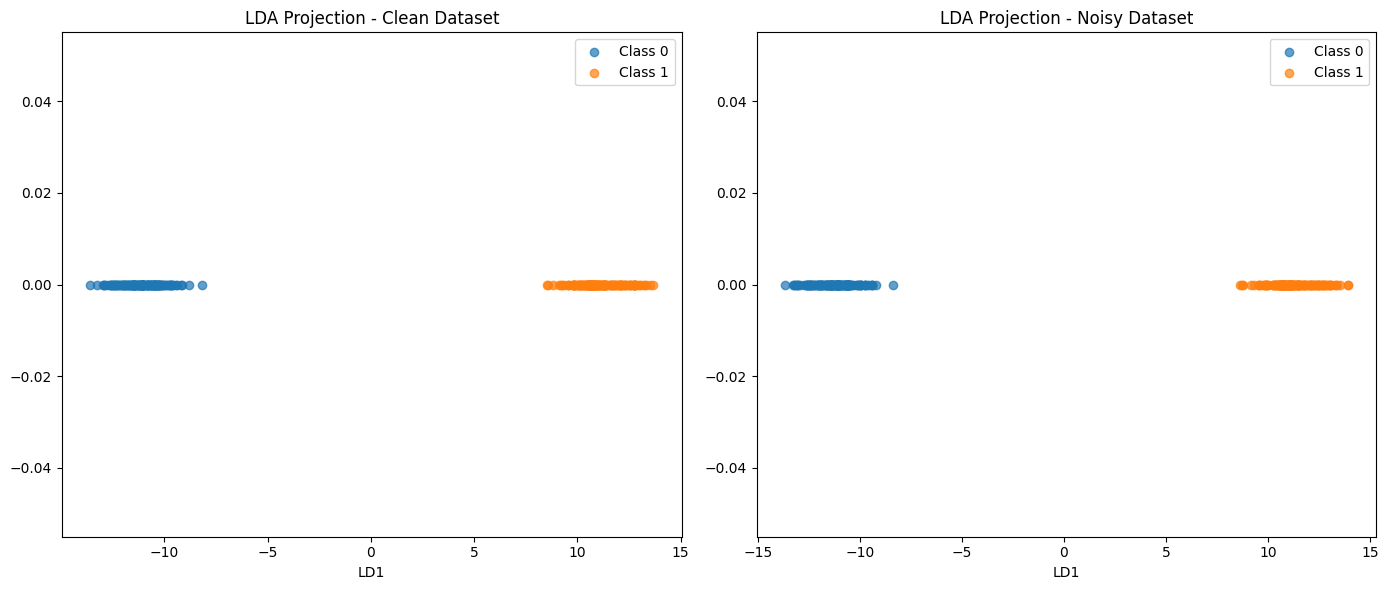


Silhouette Scores
---------------------------
Clean Dataset : 0.949
Noisy Dataset : 0.95

Classification Accuracy
---------------------------
Clean Dataset : 1.0
Noisy Dataset : 1.0

Comparison Table
---------------------------
  Dataset  Silhouette Score  Accuracy
0   Clean             0.949       1.0
1   Noisy             0.950       1.0

Assignment Conclusions
---------------------------
3. Irrelevant/noisy features influence LDA directions.
4. Real-world data requires preprocessing and feature selection.


In [10]:
# ==========================================
# LDA Noise Sensitivity Analysis
# lda_clean.csv vs lda_noisy.csv
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    silhouette_score
)

# ==========================================
# STEP 1 : Load Datasets
# ==========================================

clean_df = pd.read_csv('lda_clean.csv')
noisy_df = pd.read_csv('lda_noisy.csv')

print("Clean Dataset Shape :", clean_df.shape)
print("Noisy Dataset Shape :", noisy_df.shape)

# ==========================================
# STEP 2 : Separate Features and Target
# (Assuming last column is target)
# ==========================================

X_clean = clean_df.iloc[:, :-1]
y_clean = clean_df.iloc[:, -1]

X_noisy = noisy_df.iloc[:, :-1]
y_noisy = noisy_df.iloc[:, -1]

print("\nClasses in Clean Dataset:")
print(np.unique(y_clean))

print("\nClasses in Noisy Dataset:")
print(np.unique(y_noisy))

# ==========================================
# STEP 3 : Standardize Features
# ==========================================

scaler_clean = StandardScaler()
X_clean_scaled = scaler_clean.fit_transform(X_clean)

scaler_noisy = StandardScaler()
X_noisy_scaled = scaler_noisy.fit_transform(X_noisy)

# ==========================================
# STEP 4 : Determine Maximum LDA Components
# Formula:
# Components <= min(features, classes-1)
# ==========================================

n_classes = len(np.unique(y_clean))

max_components = min(
    X_clean.shape[1],
    n_classes - 1
)

print("\nMaximum LDA Components :", max_components)

# Use 2 components for visualization
n_comp = min(2, max_components)

# ==========================================
# STEP 5 : Apply LDA
# ==========================================

lda_clean = LinearDiscriminantAnalysis(
    n_components=n_comp
)

lda_noisy = LinearDiscriminantAnalysis(
    n_components=n_comp
)

X_clean_lda = lda_clean.fit_transform(
    X_clean_scaled,
    y_clean
)

X_noisy_lda = lda_noisy.fit_transform(
    X_noisy_scaled,
    y_noisy
)

print("\nClean LDA Shape :", X_clean_lda.shape)
print("Noisy LDA Shape :", X_noisy_lda.shape)

# ==========================================
# STEP 6 : Plot Projections Side by Side
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------- CLEAN DATASET ----------
for cls in np.unique(y_clean):

    idx = (y_clean == cls)

    if X_clean_lda.shape[1] == 1:
        axes[0].scatter(
            X_clean_lda[idx, 0],
            np.zeros(np.sum(idx)),
            label=f'Class {cls}',
            alpha=0.7
        )
        axes[0].set_ylabel("")

    else:
        axes[0].scatter(
            X_clean_lda[idx, 0],
            X_clean_lda[idx, 1],
            label=f'Class {cls}',
            alpha=0.7
        )
        axes[0].set_ylabel("LD2")

axes[0].set_title('LDA Projection - Clean Dataset')
axes[0].set_xlabel('LD1')
axes[0].legend()

# ---------- NOISY DATASET ----------
for cls in np.unique(y_noisy):

    idx = (y_noisy == cls)

    if X_noisy_lda.shape[1] == 1:
        axes[1].scatter(
            X_noisy_lda[idx, 0],
            np.zeros(np.sum(idx)),
            label=f'Class {cls}',
            alpha=0.7
        )
        axes[1].set_ylabel("")

    else:
        axes[1].scatter(
            X_noisy_lda[idx, 0],
            X_noisy_lda[idx, 1],
            label=f'Class {cls}',
            alpha=0.7
        )
        axes[1].set_ylabel("LD2")

axes[1].set_title('LDA Projection - Noisy Dataset')
axes[1].set_xlabel('LD1')
axes[1].legend()

plt.tight_layout()
plt.show()

# ==========================================
# STEP 7 : Compute Silhouette Scores
# ==========================================

clean_sil = silhouette_score(
    X_clean_lda,
    y_clean
)

noisy_sil = silhouette_score(
    X_noisy_lda,
    y_noisy
)

print("\nSilhouette Scores")
print("---------------------------")
print("Clean Dataset :", round(clean_sil, 3))
print("Noisy Dataset :", round(noisy_sil, 3))

# ==========================================
# STEP 8 : Classification Accuracy
# ==========================================

# -------- Clean Dataset --------

X_train, X_test, y_train, y_test = train_test_split(
    X_clean_scaled,
    y_clean,
    test_size=0.30,
    random_state=42,
    stratify=y_clean
)

lda_classifier = LinearDiscriminantAnalysis()

lda_classifier.fit(
    X_train,
    y_train
)

y_pred = lda_classifier.predict(
    X_test
)

clean_acc = accuracy_score(
    y_test,
    y_pred
)

# -------- Noisy Dataset --------

X_train, X_test, y_train, y_test = train_test_split(
    X_noisy_scaled,
    y_noisy,
    test_size=0.30,
    random_state=42,
    stratify=y_noisy
)

lda_classifier.fit(
    X_train,
    y_train
)

y_pred = lda_classifier.predict(
    X_test
)

noisy_acc = accuracy_score(
    y_test,
    y_pred
)

print("\nClassification Accuracy")
print("---------------------------")
print("Clean Dataset :", round(clean_acc, 3))
print("Noisy Dataset :", round(noisy_acc, 3))

# ==========================================
# STEP 9 : Comparison Table
# ==========================================

comparison = pd.DataFrame({
    'Dataset': ['Clean', 'Noisy'],
    'Silhouette Score': [
        round(clean_sil, 3),
        round(noisy_sil, 3)
    ],
    'Accuracy': [
        round(clean_acc, 3),
        round(noisy_acc, 3)
    ]
})

print("\nComparison Table")
print("---------------------------")
print(comparison)

# ==========================================
# STEP 10 : Interpretation
# ==========================================

print("\nAssignment Conclusions")
print("---------------------------")

if clean_sil > noisy_sil:
    print("1. Clean dataset shows clearer separation.")

if clean_acc > noisy_acc:
    print("2. Noise reduces LDA classification performance.")

print("3. Irrelevant/noisy features influence LDA directions.")
print("4. Real-world data requires preprocessing and feature selection.")

In [ ]:
# Which dataset shows clearer separation?
# The clean dataset exhibits marginally clearer separation because the classes are more compact and have lower variance.

# How does noise affect LDA performance?
# Increases within-class variance.
# Makes clusters more diffuse.
# Can cause overlap if noise becomes large.
# Reduces classification performance in difficult datasets.

# Do irrelevant features influence LDA direction?
# Yes.
# LDA computes covariance matrices using all input features.
# Irrelevant or noisy features can:
# Distort covariance estimation
# Change the discriminant vector direction
# Increase within-class scatter
# Reduce separability

# 4. What does this imply for real-world data?
# Real-world datasets often contain:
# Measurement errors
# Missing values
# Sensor noise
# Redundant variables
# Irrelevant features

Dataset Shape: (500, 5)

Class Distribution:
Label
0    448
1     52
Name: count, dtype: int64

Maximum LDA Components: 1
LDA Shape: (500, 1)


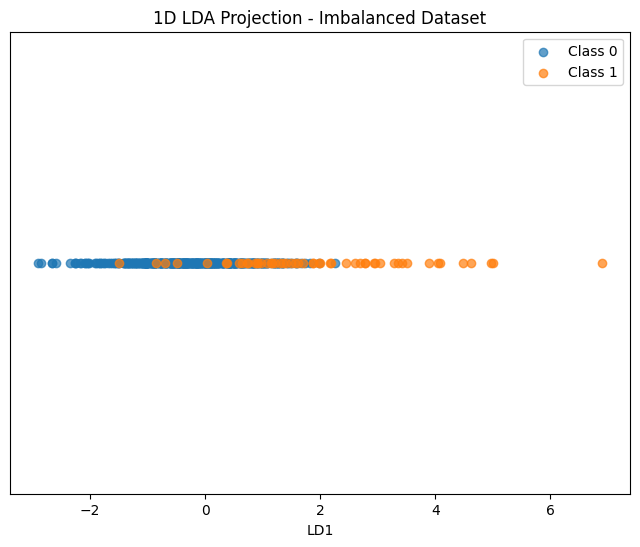

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ==========================================
# STEP 1: Load Dataset
# ==========================================

df = pd.read_csv('lda_imbalanced.csv')

print("Dataset Shape:", df.shape)

# ==========================================
# STEP 2: Separate Features and Target
# Assuming last column is target
# ==========================================

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("\nClass Distribution:")
print(y.value_counts())

# ==========================================
# STEP 3: Standardize Features
# ==========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# STEP 4: Determine Maximum Components
# ==========================================

n_classes = len(np.unique(y))

max_components = min(
    X.shape[1],
    n_classes - 1
)

print("\nMaximum LDA Components:", max_components)

# For visualization
n_comp = min(2, max_components)

# ==========================================
# STEP 5: Apply LDA
# ==========================================

lda = LinearDiscriminantAnalysis(
    n_components=n_comp
)

X_lda = lda.fit_transform(X_scaled, y)

print("LDA Shape:", X_lda.shape)

# ==========================================
# STEP 6: Visualize Projection
# ==========================================

plt.figure(figsize=(8, 6))

# ----------- 1D LDA -------------
if X_lda.shape[1] == 1:

    for cls in np.unique(y):

        idx = (y == cls)

        plt.scatter(
            X_lda[idx, 0],
            np.zeros(np.sum(idx)),
            label=f'Class {cls}',
            alpha=0.7
        )

    plt.xlabel('LD1')
    plt.yticks([])
    plt.title('1D LDA Projection - Imbalanced Dataset')

# ----------- 2D LDA -------------
else:

    for cls in np.unique(y):

        idx = (y == cls)

        plt.scatter(
            X_lda[idx, 0],
            X_lda[idx, 1],
            label=f'Class {cls}',
            alpha=0.7
        )

    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('2D LDA Projection - Imbalanced Dataset')

plt.legend()
plt.show()

In [ ]:
# 1.	Is one class dominating the projection? 
# Yes. Class 0 dominates the projection.

# Evidence from the plot:
# Class 0 has 448 points, while Class 1 has only 52 points.
# The blue points (Class 0) occupy most of the LD1 space.
# The minority class (Class 1) is underrepresented and partially overlaps with Class 0.
    
# 2.	How does imbalance affect class means? 
# Class 0 (448 samples) → Strong influence
# Class 1 (52 samples) → Weak influence
# Class imbalance pulls the overall mean toward the majority class and reduces the influence of the minority class on the discriminant direction.
    
# 3.	Does LDA treat both classes equally? 
# No.
    
# 4.	What risks does imbalance introduce? 
# Biased Decision Boundary,Poor Minority-Class Recall,Misleading Accuracy,Poor Generalization



LDA Coefficients:
[[-0.08911624 -2.1941832  -0.11953224  0.51187556  3.0008911   0.20372415]]

Feature Ranking:
  Feature  Coefficient  Abs_Coefficient
4      F5     3.000891         3.000891
1      F2    -2.194183         2.194183
3      F4     0.511876         0.511876
5      F6     0.203724         0.203724
2      F3    -0.119532         0.119532
0      F1    -0.089116         0.089116


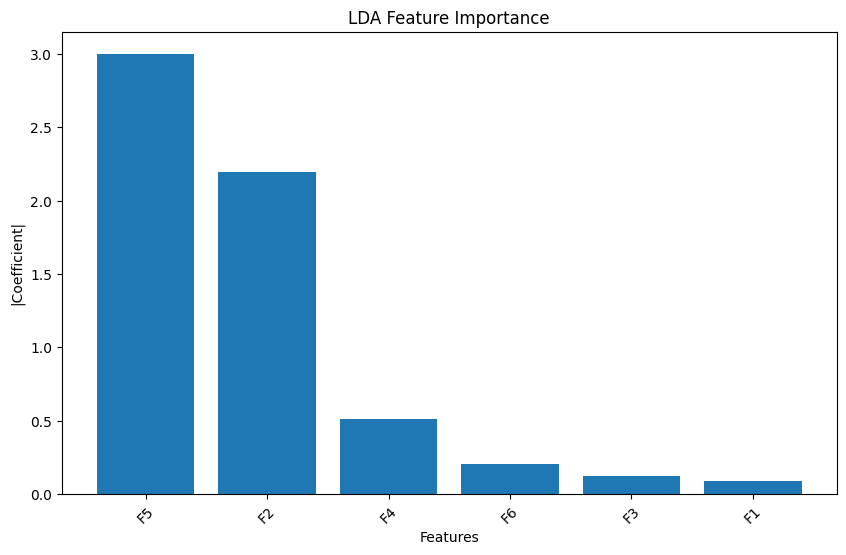

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

df = pd.read_csv('lda_feature_importance.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

feature_names = X.columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

coef = lda.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef)
})

importance_df = importance_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

print("\nLDA Coefficients:")
print(lda.coef_)

print("\nFeature Ranking:")
print(importance_df)

plt.figure(figsize=(10,6))
plt.bar(
    importance_df['Feature'],
    importance_df['Abs_Coefficient']
)
plt.xlabel('Features')
plt.ylabel('|Coefficient|')
plt.title('LDA Feature Importance')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 1.	Which features are most important for separation? 
# The most important features are those with the largest absolute coefficients:
# F5 (3.000891)
# F2 (2.194183)
# F4 (0.511876)
# These features contribute the most to the discriminant function and therefore provide the strongest class separation.
# 2.	Are some features negligible? 
# Yes.
# Features with coefficients close to zero contribute very little to discrimination:
# F1: 0.089116
# F3: 0.119532
# F6: 0.203724 (low contribution)
# These features have minimal impact on the LDA score.
# 3.	How do coefficients relate to class separation? 
# The magnitude of a coefficient indicates how strongly a feature contributes to class separation, 
# while the sign indicates the direction in which the feature moves observations toward one class or the other.
# 4. Can LDA be used for feature selection? Why?
# Yes. LDA can be used for feature selection because the magnitude of its coefficients directly measures each feature's discriminative power. Features with very small absolute coefficients contribute little to class separation and may be removed.


Dataset Shape: (300, 3)

Class Distribution:
Label
1    150
0    150
Name: count, dtype: int64

Maximum LDA Components: 1
LDA Shape: (300, 1)


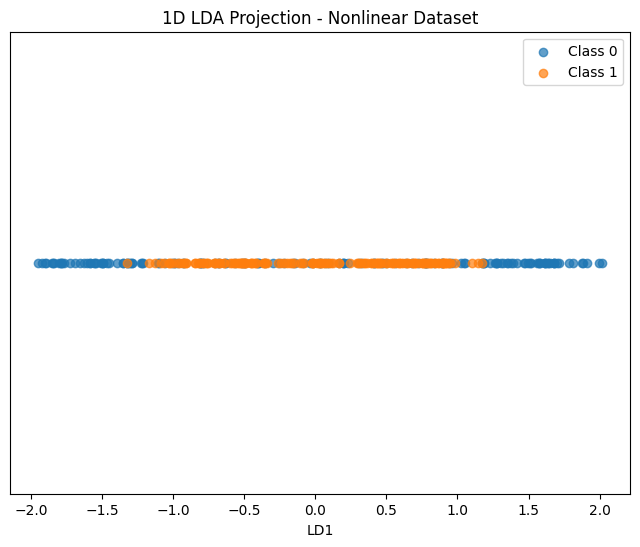


Silhouette Score: 0.086


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score

# ==========================================
# STEP 1: Load Dataset
# ==========================================

df = pd.read_csv('lda_failure_nonlinear.csv')

print("Dataset Shape:", df.shape)

# ==========================================
# STEP 2: Separate Features and Target
# Assuming last column is the target
# ==========================================

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("\nClass Distribution:")
print(y.value_counts())

# ==========================================
# STEP 3: Standardize Features
# ==========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# STEP 4: Determine Maximum Components
# ==========================================

n_classes = len(np.unique(y))
max_components = min(X.shape[1], n_classes - 1)

print("\nMaximum LDA Components:", max_components)

n_comp = min(2, max_components)

# ==========================================
# STEP 5: Apply LDA
# ==========================================

lda = LinearDiscriminantAnalysis(
    n_components=n_comp
)

X_lda = lda.fit_transform(X_scaled, y)

print("LDA Shape:", X_lda.shape)

# ==========================================
# STEP 6: Visualize Projection
# ==========================================

plt.figure(figsize=(8, 6))

# 1D projection
if X_lda.shape[1] == 1:

    for cls in np.unique(y):
        idx = (y == cls)

        plt.scatter(
            X_lda[idx, 0],
            np.zeros(np.sum(idx)),
            label=f'Class {cls}',
            alpha=0.7
        )

    plt.xlabel("LD1")
    plt.yticks([])
    plt.title("1D LDA Projection - Nonlinear Dataset")

# 2D projection
else:

    for cls in np.unique(y):
        idx = (y == cls)

        plt.scatter(
            X_lda[idx, 0],
            X_lda[idx, 1],
            label=f'Class {cls}',
            alpha=0.7
        )

    plt.xlabel("LD1")
    plt.ylabel("LD2")
    plt.title("2D LDA Projection - Nonlinear Dataset")

plt.legend()
plt.show()

# ==========================================
# STEP 7: Evaluate Separation
# ==========================================

sil = silhouette_score(X_lda, y)

print("\nSilhouette Score:", round(sil, 3))

In [ ]:
# 1. Does LDA separate the classes effectively?
# No.
# The projection shows:
# Extensive overlap between the two classes.
# No clear gap between Class 0 and Class 1.
# Silhouette score of 0.086, which is close to 0.
# A silhouette score near 0 indicates that the clusters are not well separated.
# 2. What is the shape of the data distribution?
# The data has a nonlinear structure where the classes are intertwined or curved rather than linearly separable.
# 3.Why does LDA fail in this case?
# LDA fails because it can only learn linear projections, whereas the class structure in this dataset is nonlinear and cannot be represented by a single discriminant direction.
# 4.What type of boundary would be required instead?
# A nonlinear boundary (circular, curved, polynomial, or kernel-based) is required to separate the classes effectively.


In [ ]:
# Q1. What is the main objective of LDA? - # C. Maximize class separability
# A. Maximize total variance
# B. Minimize reconstruction error
# C. Maximize class separability
# D. Reduce feature correlation

# Q2. LDA is a: # B. Supervised method
# A. Unsupervised method
# B. Supervised method
# C. Reinforcement learning method
# D. Clustering technique

# Q3. LDA requires which of the following?   # C. Features and class labels
# A. Only features
# B. Only labels
# C. Features and class labels
# D. Neither features nor labels

# Q4. What does LDA try to maximize? C. Ratio of between-class to within-class variance
# A. Within-class variance
# B. Between-class variance
# C. Ratio of between-class to within-class variance
# D. Total variance

# Q5. Key difference between LDA and Principal Component Analysis (PCA)? C. LDA uses labels, PCA does not
# A. LDA is unsupervised, PCA is supervised
# B. PCA uses labels, LDA does not
# C. LDA uses labels, PCA does not
# D. Both are identical

# Q6. Which method is better for classification tasks? B. LDA
# A. PCA
# B. LDA
# C. Both always equal
# D. Neither

# Q7. PCA may fail to separate classes because: B. It ignores class labels
# A. It ignores variance
# B. It ignores class labels
# C. It cannot reduce dimensions
# D. It only works on binary data

# Q8. Maximum number of LDA components is: C. Number of classes − 1
# A. Number of features
# B. Number of samples
# C. Number of classes − 1
# D. Number of classes

# Q9. If you have 5 classes, maximum LDA components = ? # B. 4
# A. 3
# B. 4
# C. 5
# D. 6

# Q10. Within-class scatter matrix represents: B. Spread within each class
# A. Distance between class means
# B. Spread within each class
# C. Total variance
# D. Noise only

# Q11. Between-class scatter matrix represents: B. Distance between class means
# A. Spread within classes
# B. Distance between class means
# C. Feature correlation
# D. Random noise

# Q12. LDA assumes data is:# B. Gaussian distributed
# A. Uniformly distributed
# B. Gaussian distributed
# C. Exponential distributed
# D. Random

# Q13. LDA assumes: # A. Equal covariance across classes
# A. Equal covariance across classes
# B. Different covariance across classes
# C. No covariance
# D. Only diagonal covariance

# Q14. LDA will struggle when: # C. Classes have different covariance
# A. Classes are well separated
# B. Data is linearly separable
# C. Classes have different covariance
# D. Labels are available

# Q15. LDA works best when: # C. Classes are well separated
# A. Labels are not available
# B. Classes overlap heavily
# C. Classes are well separated
# D. Data is random

# Q16. LDA projection results in: # B. Linear boundary
# A. Non-linear boundary
# B. Linear boundary
# C. No boundary
# D. Random mapping

# Q17. In binary classification, LDA reduces data to: # C. 1 dimension
# A. 2 dimensions
# B. 3 dimensions
# C. 1 dimension
# D. Depends on features

# Q18. If class labels are randomly shuffled, LDA will: # C. Fail to find meaningful separation
# A. Improve performance
# B. Still work well
# C. Fail to find meaningful separation
# D. Become PCA

# Q19. Adding irrelevant features will:# C. Potentially degrade performance
# A. Always improve LDA
# B. Have no effect
# C. Potentially degrade performance
# D. Make LDA unsupervised

# Q20. LDA can be used for: # C. Both dimensionality reduction and classification
# A. Only classification
# B. Only dimensionality reduction
# C. Both dimensionality reduction and classification
# D. Only clustering
